In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
from src.feature_generation import build_feature_bank, extract_encoder, pool_features
from src.preprocessing import BioacousticDataset
import pandas as pd
import pickle
from pathlib import Path
import os
from src.preprocessing import PipistrellePreprocessingPipeline
import matplotlib.pyplot as plt
import librosa
import librosa.display
import matplotlib.gridspec as gridspec

c:\Users\anast\miniconda3\envs\temp-env-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from avex import list_models

In [5]:
print(list_models().keys())


Model Name                          Description                              Trained Classifier  
esp_aves2_eat_all                   eat_hf (pretrained backbone)             ❌ No                
esp_aves2_eat_bio                   eat_hf (pretrained backbone)             ❌ No                
esp_aves2_effnetb0_all              efficientnet (fine-tuned) - 12806 classes ✅ Yes (12806 classes)
esp_aves2_effnetb0_audioset         efficientnet (pretrained backbone)       ❌ No                
esp_aves2_effnetb0_bio              efficientnet (fine-tuned) - 12279 classes ✅ Yes (12279 classes)
esp_aves2_naturelm_audio_v1_beats   beats (pretrained backbone) - NatureLM   ❌ No                
esp_aves2_sl_beats_all              beats (fine-tuned) - 12806 classes - fine-tuned ✅ Yes (12806 classes)
esp_aves2_sl_beats_bio              beats (fine-tuned) - 12279 classes - fine-tuned ✅ Yes (12279 classes)
esp_aves2_sl_eat_all_ssl_all        eat_hf (fine-tuned) - 12806 classes      ✅ Yes (12806 classes

In [6]:
from huggingface_hub import hf_hub_download

In [7]:
model_path = hf_hub_download(
    repo_id="justinchuby/Perch-onnx",
    filename="perch_v2.onnx"
)

c:\Users\anast\miniconda3\envs\temp-env-1\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anast\.cache\huggingface\hub\models--justinchuby--Perch-onnx. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [8]:
import onnxruntime as ort
session = ort.InferenceSession(
    model_path,  # the string path returned by hf_hub_download
    providers=["CPUExecutionProvider"]  # or ["CUDAExecutionProvider", "CPUExecutionProvider"] if you have GPU
)

# sanity check the input/output names match what you expect
print([i.name for i in session.get_inputs()])   # should print ['inputs']
print([o.name for o in session.get_outputs()])  # ['embedding', 'spatial_embedding', 'spectrogram', 'label']

['inputs']
['embedding', 'spatial_embedding', 'spectrogram', 'label']


In [7]:
dir = Path(os.getcwd()).resolve().parent / "data"
df = pd.read_csv(str(dir / "bat_metadata.csv"))
label_cols = ['type_a', 'type_b', 'type_c', 'type_d', 'echo']
X_paths = df['relative_path'].values
y_labels = df[label_cols].values
file_path = os.path.join(str(dir / "xenocanto-dataset"), X_paths[0])
window = PipistrellePreprocessingPipeline(target_sr=32000, expansion_factor=5,window_sec =5,overlap=0.5).forward(file_path)

In [22]:
print(window)

tensor([[-4.6306e-04,  9.8645e-04,  2.7062e-04,  ..., -2.5077e-04,
          4.0285e-05,  2.1126e-04],
        [ 1.8578e-04,  3.1567e-04, -7.3519e-05,  ...,  1.1061e-04,
          1.5090e-05,  1.0016e-05],
        [ 1.1980e-04,  1.2116e-04, -1.5887e-04,  ...,  9.1934e-05,
         -1.6061e-04, -1.7536e-04],
        ...,
        [ 4.6335e-05, -1.1590e-04, -1.1796e-04,  ...,  3.2472e-04,
          1.1815e-04, -5.4441e-05],
        [-1.4111e-04,  1.5793e-04,  3.8589e-05,  ..., -1.6728e-04,
         -2.8184e-04, -1.2719e-04],
        [-1.0555e-04, -2.2995e-04,  1.8377e-04,  ...,  6.3963e-05,
         -7.5156e-05, -1.0797e-04]])


In [23]:
print(window.shape)

torch.Size([104, 160000])


In [ ]:
window2 = window.numpy().astype(np.float32)
outputs = session.run(
    ["spatial_embedding"],           # only request what you need — cheaper than pulling all 4 outputs
    {"inputs": window2}
)
embeddings = outputs[0]      # shape (n_windows, 1536)

In [25]:
print(embeddings.shape)

(104, 16, 4, 1536)


In [26]:
file_path2 = os.path.join(str(dir / "xenocanto-dataset"), X_paths[1])
window3 = PipistrellePreprocessingPipeline(target_sr=32000, expansion_factor=5,window_sec =5,overlap=0.5).forward(file_path2).numpy().astype(np.float32)
outputs2 = session.run(
    ["spatial_embedding"],           # only request what you need — cheaper than pulling all 4 outputs
    {"inputs": window3}
)
embeddings2 = outputs2[0]  


In [31]:
from src.feature_generation import build_perch_fb
batdata = BioacousticDataset(data_input=str(dir / "bat_metadata.csv"),
                             root_dir=str(dir / "xenocanto-dataset"),
                             encoder = "perch2")

X_bags, labels = build_perch_fb(batdata)

Dataset type: <class 'src.preprocessing.BioacousticDataset'>


Extracting perch 2.0:   8%|▊         | 23/284 [03:54<44:18, 10.19s/it]  


KeyboardInterrupt: 

In [8]:
import soundfile as sf
from collections import Counter

sr_counts = Counter()
for path in X_paths:
    info = sf.info(str(dir / "xenocanto-dataset" / path))
    sr_counts[info.samplerate] += 1

print(sr_counts)

Counter({256000: 209, 312500: 35, 384000: 20, 192000: 13, 441000: 4, 500000: 2, 200000: 1, 250000: 1})


In [9]:
import soundfile as sf

target_srs = {96000, 44100}
for path in X_paths:
    info = sf.info(str(dir / "xenocanto-dataset" / path))
    if info.samplerate in target_srs:
        print(path, info.samplerate)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
encoder = "perch2"
encoder_model = extract_encoder(encoder)
dir = Path(os.getcwd()).resolve().parent / "data"
batdata = PipistrelleDataset(data_input=str(dir / "bat_metadata.csv"),
                             root_dir=str(dir / "xenocanto-dataset"),
                             encoder = encoder,
                             filter_echo = False)

X_bags,labels = build_feature_bank(batdata, encoder_model, encoder, device=device)

In [ ]:
pickle_filename = 'perch2-bags.pkl'
with open(pickle_filename, 'wb') as pickle_file:
    pickle.dump(X_bags, pickle_file)

[sample] C:\Users\anast\Desktop\College\IDIAP internship\bat-project\data\xenocanto-dataset\type D\XC1031442 - Common Pipistrelle - Pipistrellus pipistrellus.wav  (window 50/57)


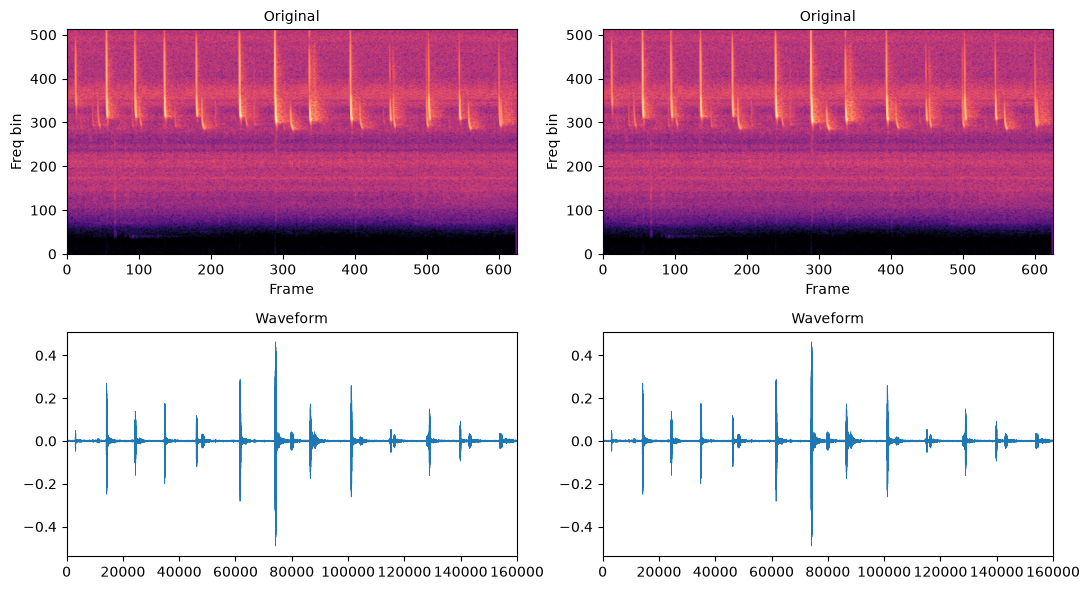

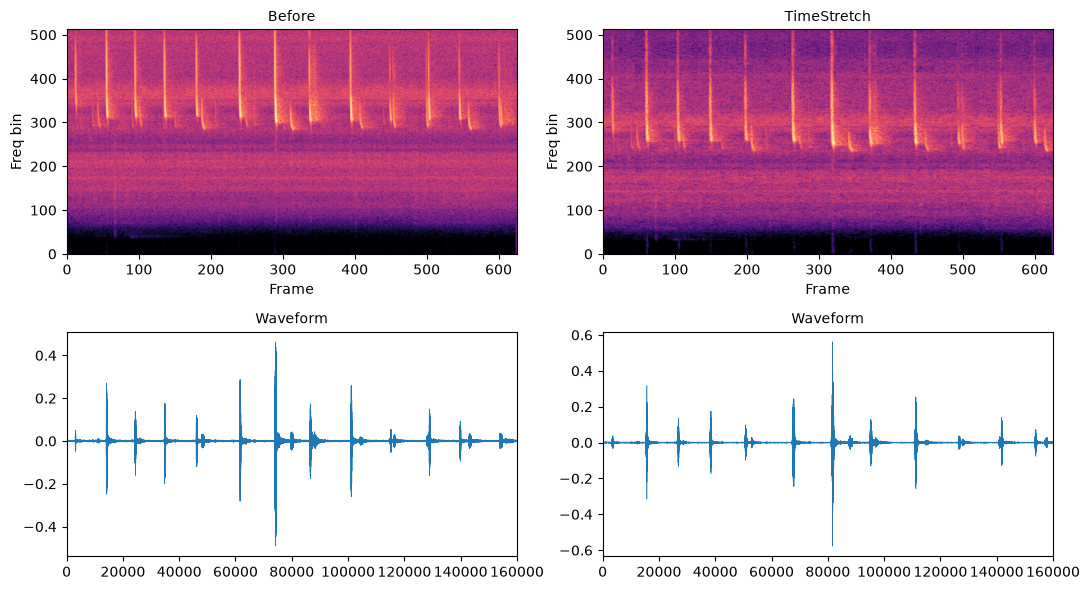

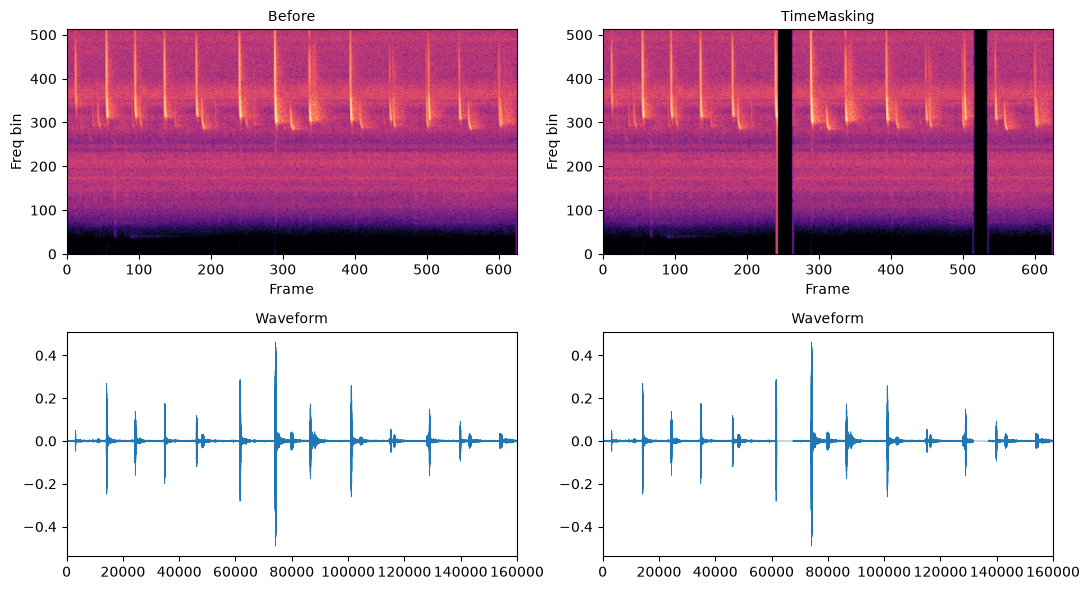

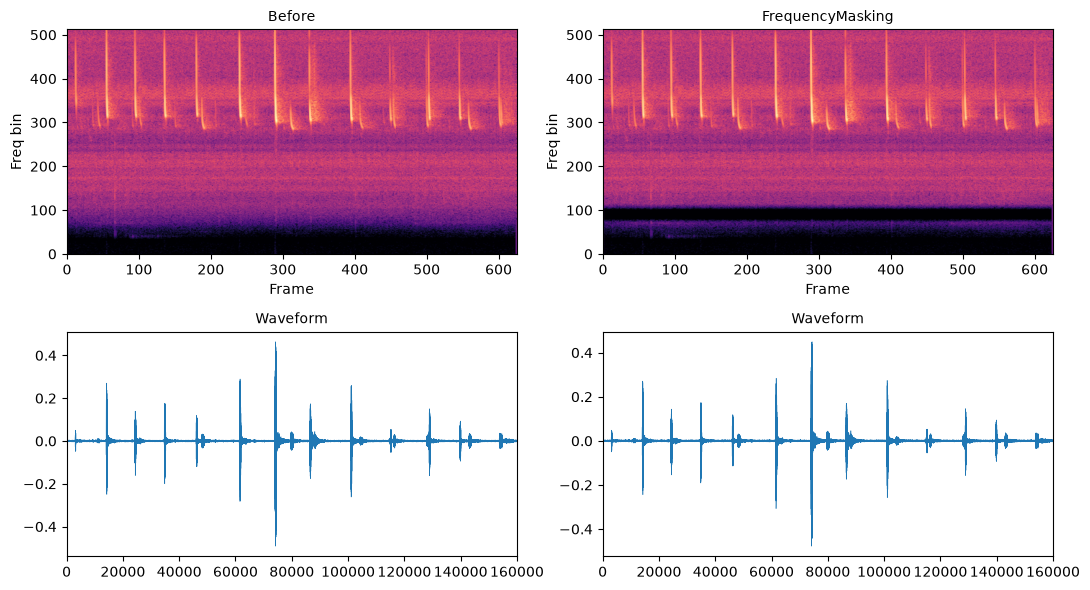

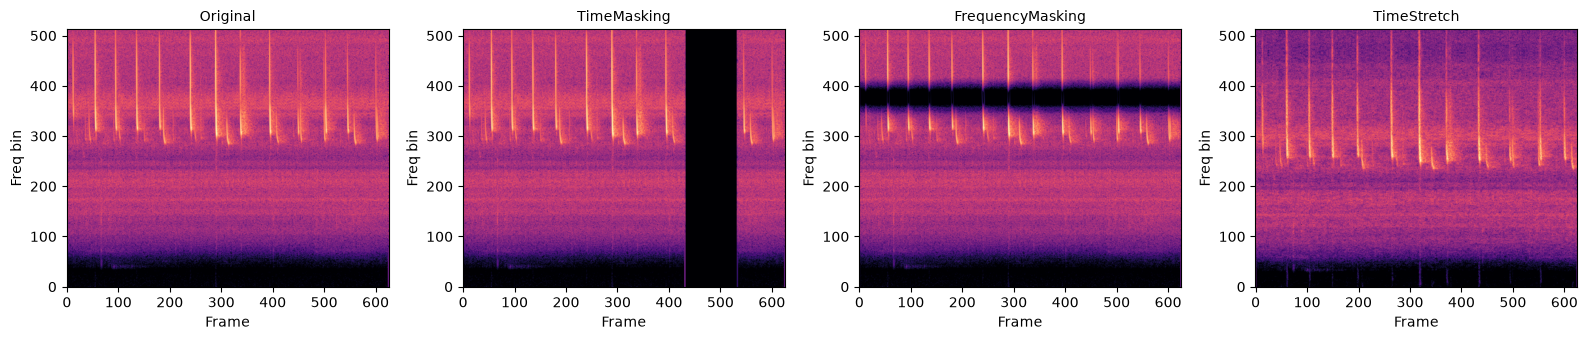

[mixup partner] C:\Users\anast\Desktop\College\IDIAP internship\bat-project\data\xenocanto-dataset\type C\XC917413 - Common Pipistrelle - Pipistrellus pipistrellus.wav (window 9)


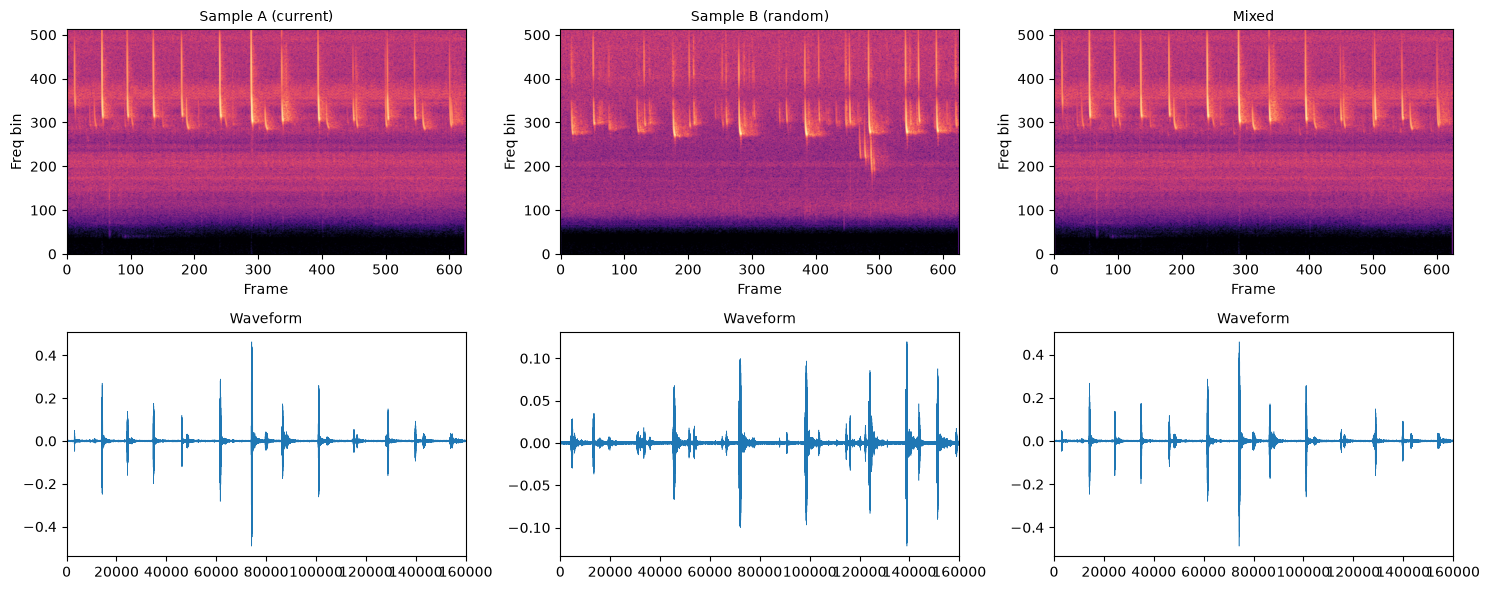

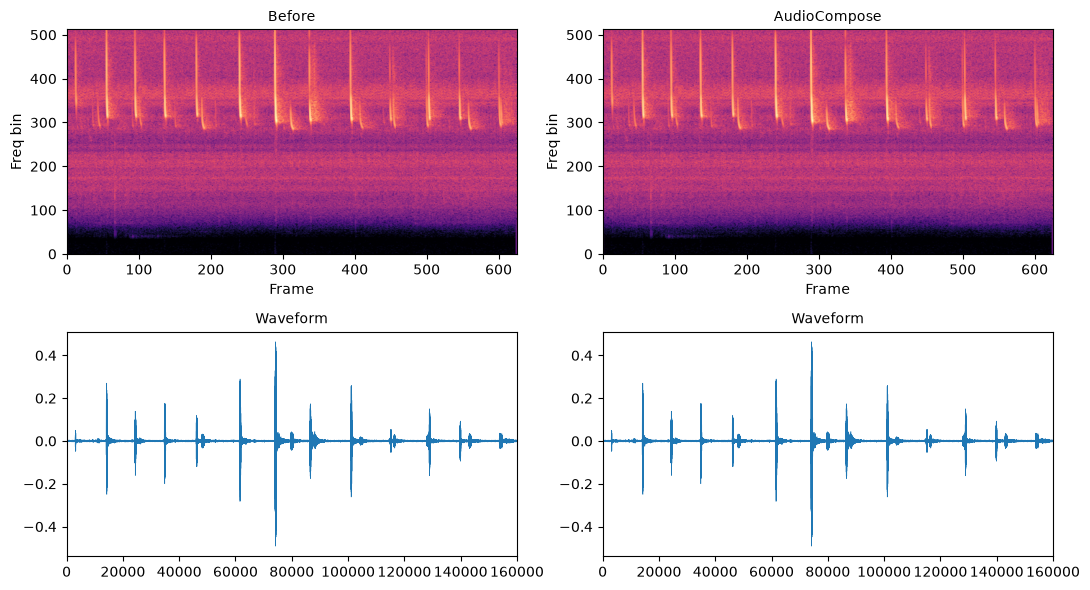

tensor([[-0.0011,  0.0026, -0.0003,  ...,  0.0026,  0.0016, -0.0028]])

In [ ]:
from augmentation_test import AugmentationVisualizer
from src.preprocessing import PipistrellePreprocessingPipeline, TimeMasking, FrequencyMasking, TimeStretch, WaveformMixup, AudioCompose

root_dir = str(dir / "xenocanto-dataset")
pipeline = PipistrellePreprocessingPipeline(target_sr=32000, expansion_factor=5, window_sec=5, overlap=0.5)
audio_paths = [os.path.join(root_dir, p) for p in df['relative_path']]

viz = AugmentationVisualizer(pipeline, audio_paths, target_sr=32000)

viz.new_sample()                 # grabs a random file + window, plots it (rerun for a new sample)
viz.apply(TimeStretch())
viz.apply(TimeMasking())         # plots before/after spectrogram + waveform (rerun to reroll)
viz.apply(FrequencyMasking())

viz.compare_grid({               # all transforms side-by-side on the same window
    "TimeMasking": TimeMasking(),
    "FrequencyMasking": FrequencyMasking(),
    "TimeStretch": TimeStretch(),
})

viz.apply_mixup(WaveformMixup(alpha=0.8))   # blends current sample with a random second one

viz.apply(AudioCompose(transforms_with_probs=[(TimeStretch(), 0.5), (WaveformMixup(), 0.3)]))  # sanity-check the full AudioCompose chain end-to-end